<a href="https://colab.research.google.com/github/Alimusy/OIBSIP/blob/main/Unemployment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the datasets
df_india = pd.read_csv('Unemployment in India.csv')
df_rate = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')

# Use the larger dataset (df_india) as the primary 'df' for further analysis
df = df_india.copy()

In [8]:
# Select the key numerical columns for descriptive statistics
numerical_cols = [
    ' Estimated Unemployment Rate (%)',
    ' Estimated Employed',
    ' Estimated Labour Participation Rate (%)'
]

# Check the actual column names in the DataFrame
print("Columns in the DataFrame:")
print(df.columns)

# Make sure to use the correct column names from the DataFrame for descriptive statistics
# If the column names in numerical_cols are incorrect, update them based on the print output above.
# For example, if the correct column name is 'Estimated Unemployment Rate (%) ', note the extra space, you should use that.
print("\nDescriptive Statistics for Key Unemployment Metrics:")
display(df[numerical_cols].describe())

Columns in the DataFrame:
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

Descriptive Statistics for Key Unemployment Metrics:


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


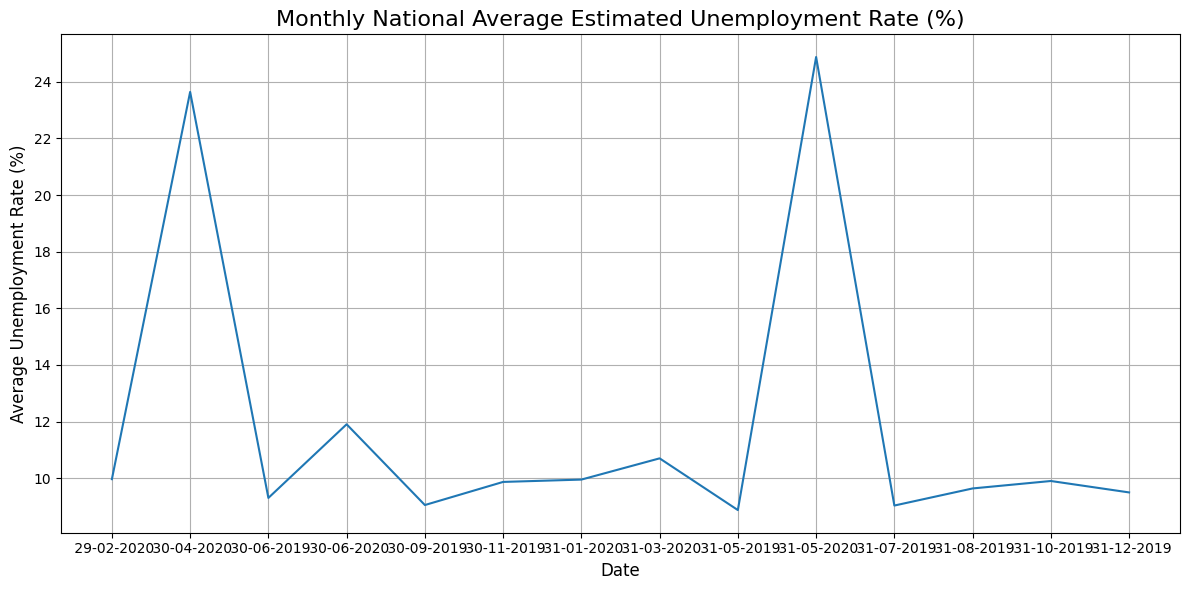

In [11]:
# 1. Group data by Date and calculate the national average unemployment rate
unemp_ts = df.groupby(' Date')[' Estimated Unemployment Rate (%)'].mean().reset_index()

# 2. Plotting the time series
plt.figure(figsize=(12, 6))
sns.lineplot(data=unemp_ts, x=' Date', y=' Estimated Unemployment Rate (%)')

# Add titles and labels for clarity
plt.title('Monthly National Average Estimated Unemployment Rate (%)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Unemployment Rate (%)', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show() # Use plt.show() for project work

/tmp/ipython-input-452651389.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


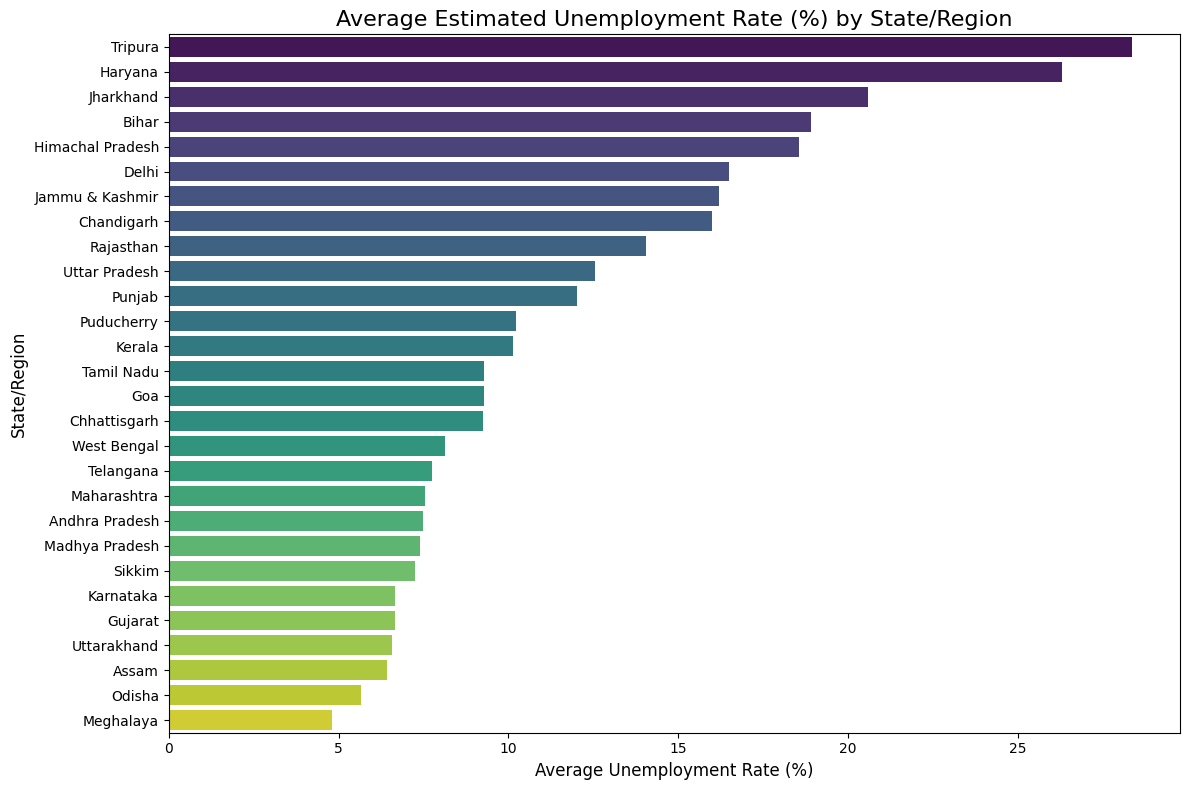

In [15]:
# 1. Calculate the average unemployment rate by Region and sort
unemp_region = (
    df.groupby('Region')[' Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# 2. Plotting the regional comparison
plt.figure(figsize=(12, 8))
sns.barplot(
    data=unemp_region,
    x=' Estimated Unemployment Rate (%)',
    y='Region',
    palette='viridis' # Use a different color palette for visual appeal
)

# Add titles and labels
plt.title('Average Estimated Unemployment Rate (%) by State/Region', fontsize=16)
plt.xlabel('Average Unemployment Rate (%)', fontsize=12)
plt.ylabel('State/Region', fontsize=12)
plt.tight_layout()
plt.show() # Use plt.show() for project work

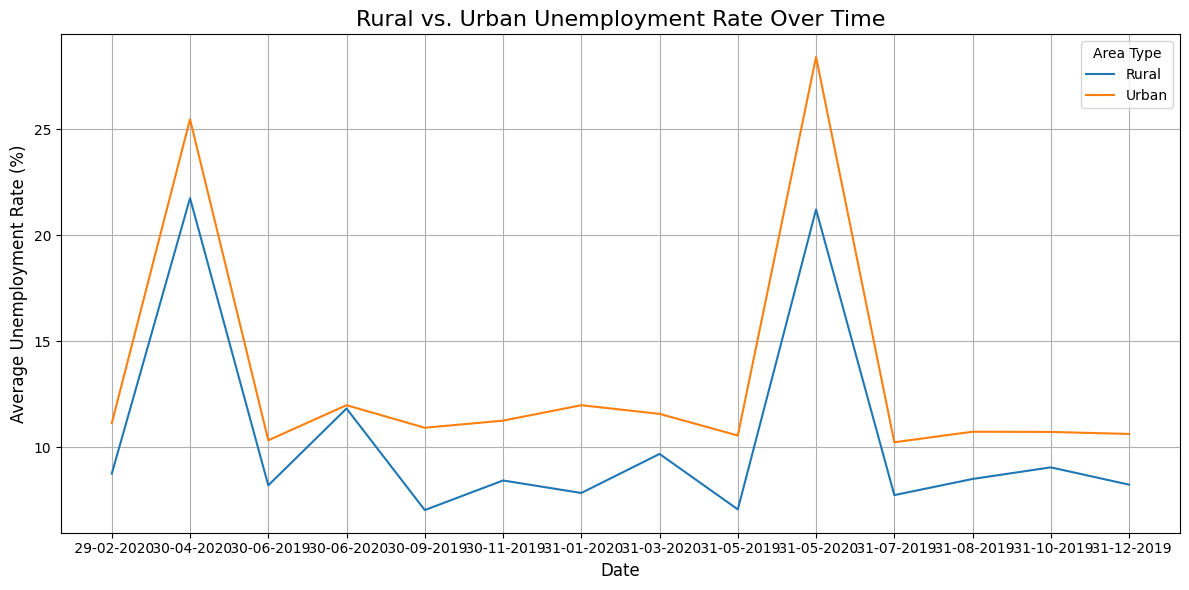

In [17]:
# Group by Date and Area, then calculate the mean unemployment rate
unemp_area_ts = df.groupby([' Date', 'Area'])[' Estimated Unemployment Rate (%)'].mean().reset_index()

# Plotting the rural vs. urban trend
plt.figure(figsize=(12, 6))
# Use the hue parameter to plot separate lines for each 'Area'
sns.lineplot(data=unemp_area_ts, x=' Date', y=' Estimated Unemployment Rate (%)', hue='Area')

plt.title('Rural vs. Urban Unemployment Rate Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Unemployment Rate (%)', fontsize=12)
plt.legend(title='Area Type')
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipython-input-1641544059.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


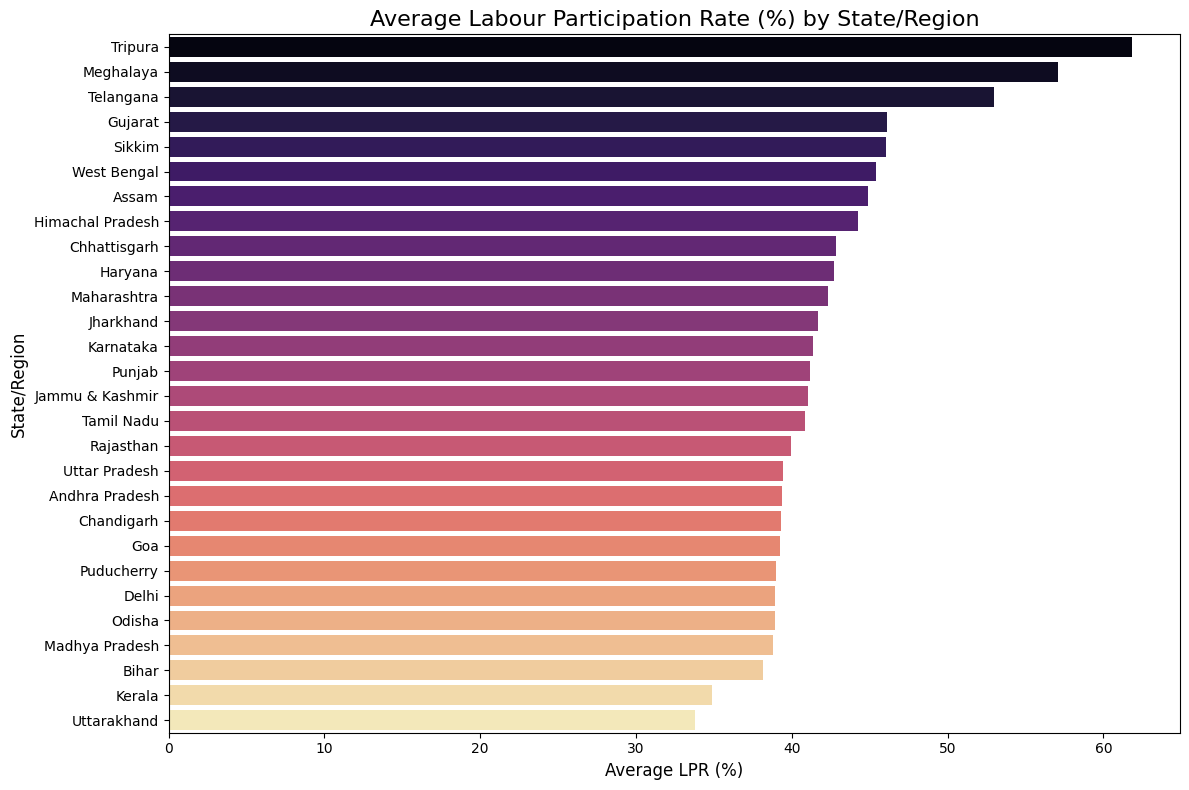

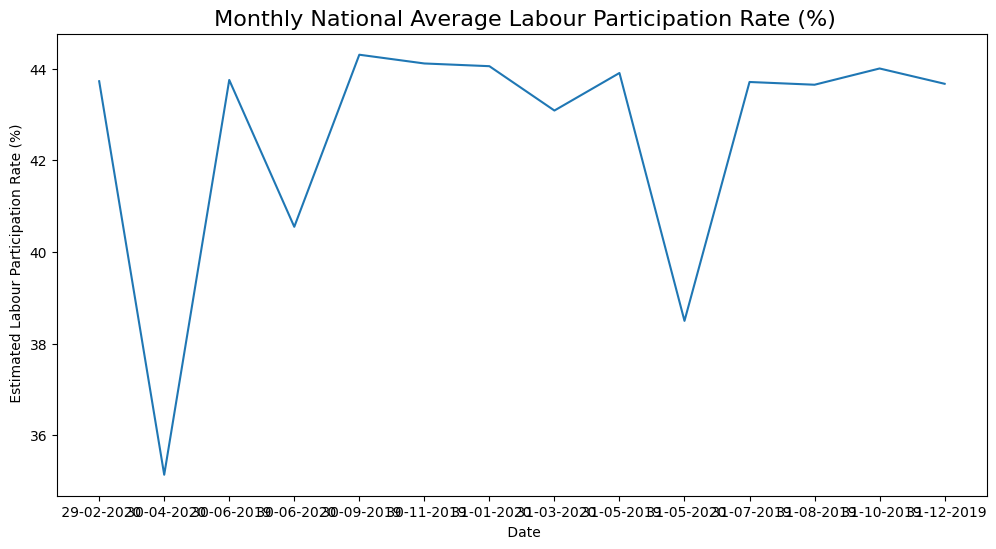

In [24]:
# Regional LPR comparison
lpr_region = (
    df.groupby('Region')[' Estimated Labour Participation Rate (%)']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=lpr_region,
    x=' Estimated Labour Participation Rate (%)',
    y='Region',
    palette='magma' # Use a different palette
)
plt.title('Average Labour Participation Rate (%) by State/Region', fontsize=16)
plt.xlabel('Average LPR (%)', fontsize=12)
plt.ylabel('State/Region', fontsize=12)
plt.tight_layout()
plt.show()

# LPR Time-Series (Optional)
lpr_ts = df.groupby(' Date')[' Estimated Labour Participation Rate (%)'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=lpr_ts, x=' Date', y=' Estimated Labour Participation Rate (%)')
plt.title(' Monthly National Average Labour Participation Rate (%)', fontsize=16)
plt.show()


Correlation Matrix:
                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                 1.000000   
Estimated Employed                                             -0.245176   
Estimated Labour Participation Rate (%)                        -0.073540   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                   -0.245176   
Estimated Employed                                 1.000000   
Estimated Labour Participation Rate (%)           -0.047948   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                        -0.073540  
Estimated Employed                                                     -0.047948  
Estimated Labour Participation Rate (%)                                 1.000000  


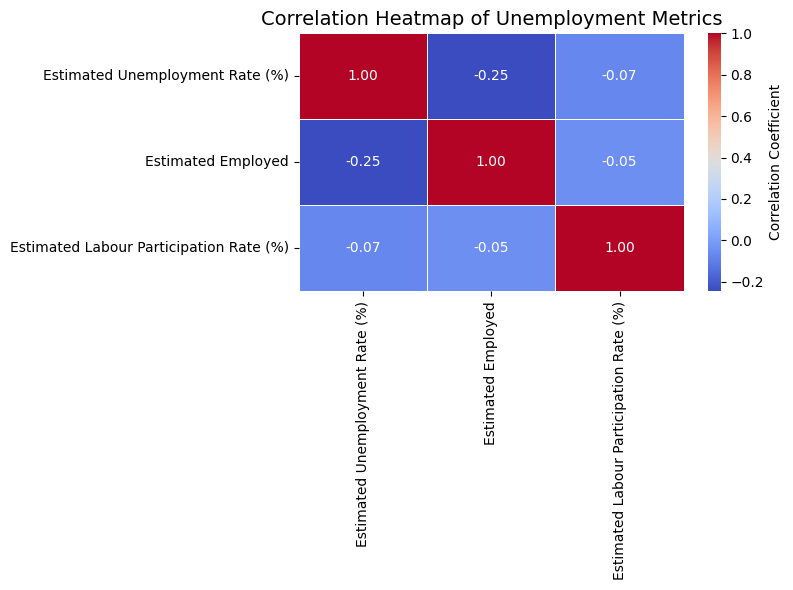

In [28]:
# Use the second dataset (df_rate) for cleaner correlation
df_corr = df_rate.copy()

# Clean and prepare the correlation data
df_corr.columns = df_corr.columns.str.strip()
df_corr['Estimated Employed'] = df_corr['Estimated Employed'].astype(float)

# Calculate the correlation matrix
correlation_matrix = df_corr[[
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)'
]].corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm', # Color scheme
    fmt=".2f", # Format to 2 decimal places
    linewidths=.5, # Lines between cells
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Heatmap of Unemployment Metrics', fontsize=14)
plt.tight_layout()
plt.show()